Number of FITS files: 376
(4, 24, 24)
(24, 24, 3)


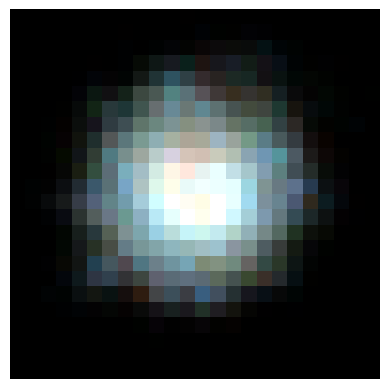

In [2]:
import pest
import matplotlib.pyplot as plt

plt.rcParams["text.usetex"] = False

# ds = pest.FitsDataset("/urz/gpuscratch/its/doserbd/data/SKIRT_synthetic_images/fits")
ds = pest.FitsDataset("../data/SKIRT_synthetic_images/fits/TNG50/sdss/snapnum_099/data")
print("Number of FITS files:", len(ds))
image = ds[5]["image"]
print(image.shape)

image = pest.CreateNormalizedRGBColors(
    stretch=0.9,
    range=5,
    lower_limit=0.001,
    channel_combinations=[[2, 3], [1, 0], [0]],
    scalers=[0.7, 0.5, 1.3],
)(image)
image = image.transpose(1, 2, 0)
print(image.shape)

# Problematic cases:
# 1: Ellipse is not well defined
# 55555: Rotational edge is visible

plt.imshow(image)
plt.axis("off")
plt.show()

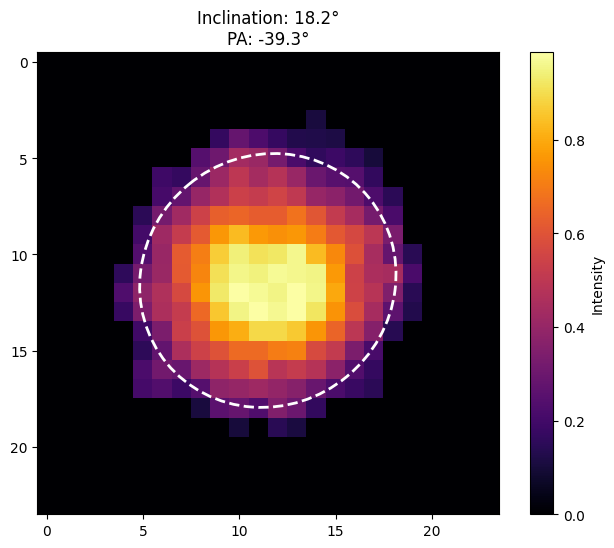

In [3]:
stats = pest.estimate_geometry_weighted(image)
pest.visualize_results(stats)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.006231411618772239..1.0279277789004158].


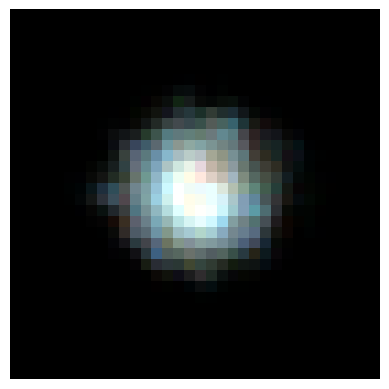

In [4]:
rotated_image = pest.align_image_horizontally(image, stats["pa_rad"])
plt.imshow(rotated_image)
plt.axis("off")
plt.show()

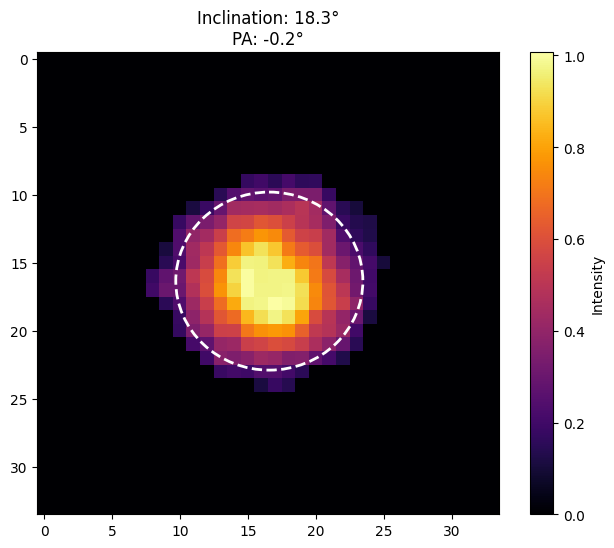

In [5]:
stats_rot = pest.estimate_geometry_weighted(rotated_image)
pest.visualize_results(stats_rot)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.006231411618772239..1.0279277789004158].


Cropped shape: (33, 33, 3)


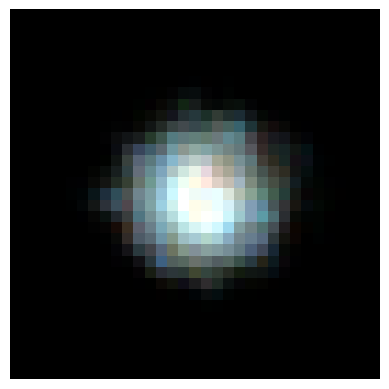

In [6]:
MARGIN = 10
croped_image = pest.crop_quadratic(rotated_image, stats_rot["centroid"], stats_rot["major_axis"] + MARGIN)
print(f"Cropped shape: {croped_image.shape}")

plt.imshow(croped_image)
plt.axis("off")
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.00533444820758989..1.0225800227461077].


Scaled shape: (128, 128, 3)


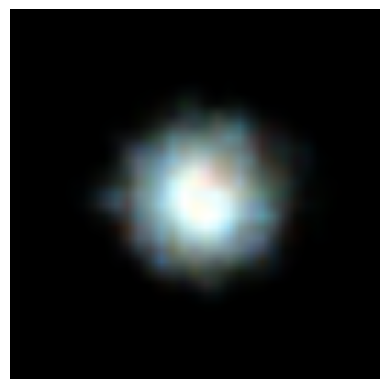

In [7]:
from skimage.transform import resize

scaled_image = resize(croped_image, (128, 128), anti_aliasing=True)
print(f"Scaled shape: {scaled_image.shape}")

plt.imshow(scaled_image)
plt.axis("off")
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.00533444820758989..1.0225800227461077].


Canonicalized shape: (128, 128, 3)


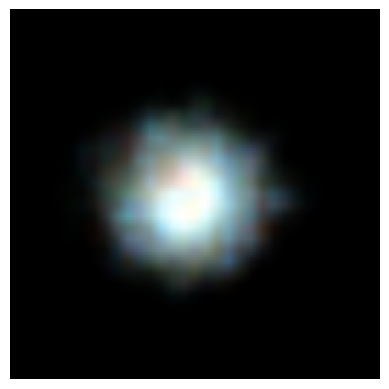

In [8]:
canonicalized_image = pest.reflectional_invariance(scaled_image)
print(f"Canonicalized shape: {canonicalized_image.shape}")

plt.imshow(canonicalized_image)
plt.axis("off")
plt.show()